# "Human Learning" with iris data

Can you predict the species of an iris using petal and sepal measurements?

TASKS:
1. Read iris data into a pandas DataFrame, including column names.
2. Gather some basic information about the data.
3. Use groupby, sorting, and/or plotting to look for differences between species.
4. Come up with a set of rules that could be used to predict species based upon measurements.

BONUS: Define a function that accepts a row of data and returns a predicted species.
Then, use that function to make predictions for all existing rows of data.

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

## Task 1

In [4]:
# read the iris data into a pandas DataFrame, including column names
df = pd.read_csv('iris.csv', header=0, names=['sepal_length', 'sepal_width', 'petal_length', 'petal_width', 'species'])
df.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


## Task 2

In [5]:
# gather basic information
df.info()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
 4   species       150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB


sepal_length    0
sepal_width     0
petal_length    0
petal_width     0
species         0
dtype: int64

In [6]:
df.describe()

,sepal_length,sepal_width,petal_length,petal_width
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.054000,3.758667,1.198667
std,0.828066,0.433594,1.764420,0.763161
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


In [7]:
df.shape

(150, 5)

## Task 3

In [8]:
# use groupby to look for differences between the species
dif_species = df.groupby('species').mean()
dif_species

,sepal_length,sepal_width,petal_length,petal_width
species,,,,
setosa,5.006,3.418,1.464,0.244
versicolor,5.936,2.770,4.260,1.326
virginica,6.588,2.974,5.552,2.026


In [9]:
# use sorting to look for differences between the species
dif_species_sorted = dif_species.sort_values(by='species', ascending=False)
dif_species_sorted

,sepal_length,sepal_width,petal_length,petal_width
species,,,,
virginica,6.588,2.974,5.552,2.026
versicolor,5.936,2.770,4.260,1.326
setosa,5.006,3.418,1.464,0.244


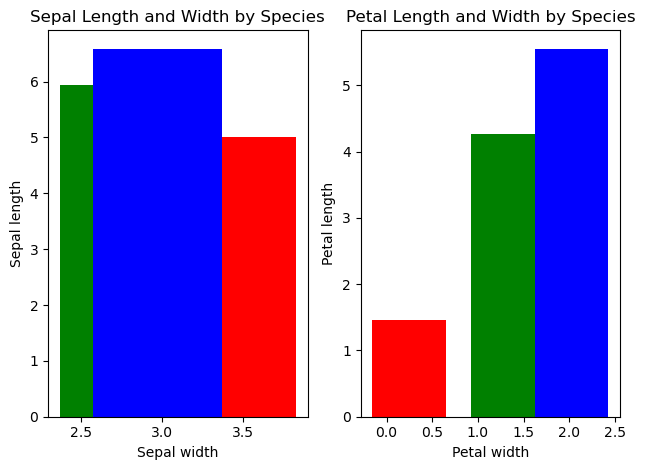

"\nimport matplotlib.pyplot as plt\nimport seaborn as sns\n\n# SOL GRAFİK: Çanak Yaprak Dağılımı\nplt.subplot(1, 2, 1)\nplt.title('Sepal Length vs Width')\n# x ve y eksenine ham sütunları veriyoruz, hue='species' diyerek türleri renklendiriyoruz\nsns.scatterplot(data=df, x='sepal_width', y='sepal_length', hue='species')\n\n# SAĞ GRAFİK: Taç Yaprak Dağılımı\nplt.subplot(1, 2, 2)\nplt.title('Petal Length vs Width')\nsns.scatterplot(data=df, x='petal_width', y='petal_length', hue='species')\n\nplt.tight_layout()\nplt.show()\n"

In [14]:
# use plotting to look for differences between the species

sepal_l = df.groupby('species')['sepal_length'].mean()
sepal_w = df.groupby('species')['sepal_width'].mean()
petal_l = df.groupby('species')['petal_length'].mean()
petal_w = df.groupby('species')['petal_width'].mean()

plt.subplot(1,2,1)
plt.title('Sepal Length and Width by Species')
plt.xlabel('Sepal width')
plt.ylabel('Sepal length')
plt.xlim()
plt.bar(sepal_w, sepal_l,  color=['red', 'green', 'blue'])   

plt.subplot(1,2,2)
plt.title('Petal Length and Width by Species')
plt.xlabel('Petal width')
plt.ylabel('Petal length')
plt.bar(petal_w, petal_l,  color=['red', 'green', 'blue'])

plt.tight_layout()
plt.show()
'''
import matplotlib.pyplot as plt
import seaborn as sns

# SOL GRAFİK: Çanak Yaprak Dağılımı
plt.subplot(1, 2, 1)
plt.title('Sepal Length vs Width')
# x ve y eksenine ham sütunları veriyoruz, hue='species' diyerek türleri renklendiriyoruz
sns.scatterplot(data=df, x='sepal_width', y='sepal_length', hue='species')

# SAĞ GRAFİK: Taç Yaprak Dağılımı
plt.subplot(1, 2, 2)
plt.title('Petal Length vs Width')
sns.scatterplot(data=df, x='petal_width', y='petal_length', hue='species')

plt.tight_layout()
plt.show()
'''

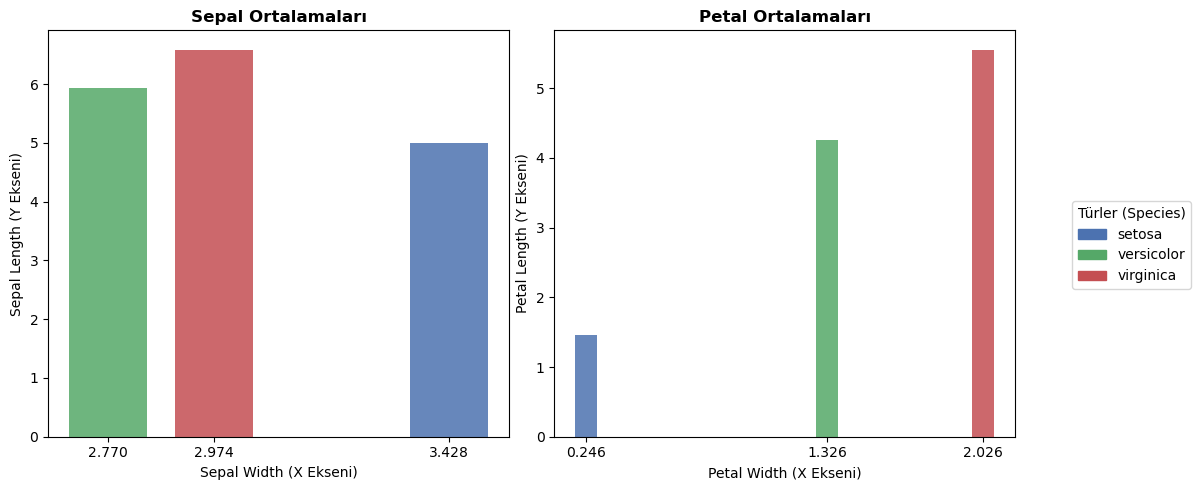

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

# Veriyi yüklüyoruz (df olarak isimlendirdik)
df = sns.load_dataset('iris')

# Sizin belirttiğiniz X ve Y ekseni değerlerini oluşturuyoruz
sepal_length = df.groupby('species')['sepal_length'].mean()
sepal_width = df.groupby('species')['sepal_width'].mean()
petal_length = df.groupby('species')['petal_length'].mean()
petal_width = df.groupby('species')['petal_width'].mean()

# Türlerin isimleri ve renkleri
species_list = sepal_length.index
colors = ['#4c72b0', '#55a868', '#c44e52']

# Yan yana 2 basit grafik açıyoruz
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# --- 1. GRAFİK: SEPAL (Çanak Yaprak) ---
# x = genişlik ortalaması, height = uzunluk (yükseklik) ortalaması
ax1.bar(x=sepal_width, height=sepal_length, width=0.15, color=colors, alpha=0.85)
ax1.set_title('Sepal Ortalamaları', fontweight='bold')
ax1.set_xlabel('Sepal Width (X Ekseni)')
ax1.set_ylabel('Sepal Length (Y Ekseni)')
ax1.set_xticks(sepal_width)  # X ekseninde tam genişlik değerleri yazar

# --- 2. GRAFİK: PETAL (Taç Yaprak) ---
# x = genişlik ortalaması, height = uzunluk (yükseklik) ortalaması
ax2.bar(x=petal_width, height=petal_length, width=0.10, color=colors, alpha=0.85)
ax2.set_title('Petal Ortalamaları', fontweight='bold')
ax2.set_xlabel('Petal Width (X Ekseni)')
ax2.set_ylabel('Petal Length (Y Ekseni)')
ax2.set_xticks(petal_width)  # X ekseninde tam genişlik değerleri yazar

# --- Sadece Renkler ve Legend ---
labels = [plt.Rectangle((0,0),1,1, color=colors[i]) for i in range(len(species_list))]
fig.legend(labels, species_list, loc='center right', title='Türler (Species)')

plt.tight_layout()
plt.subplots_adjust(right=0.85)
plt.show()

In [12]:
# map species to a numeric value so that plots can be colored by category
species_list = sepal_length.index
colors = ['#4c72b0', '#55a868', '#c44e52']
#yukaridaki bu iki satir bunu isi gordugunu dusunuyorum.


## Task 4

In [17]:
sepal_length = df.groupby('species')['sepal_length'].mean()
sepal_width = df.groupby('species')['sepal_width'].mean()
petal_length = df.groupby('species')['petal_length'].mean()
petal_width = df.groupby('species')['petal_width'].mean()

if sepal_length['virginica'] > 6.0 and petal_length['virginica'] > 5.0:
    print("Bu tür Iris-virginica olabilir.")
elif sepal_length['versicolor'] > 5.0 and petal_length['versicolor'] > 4.0:
    print("Bu tür Iris-versicolor olabilir.")
else:
    print("Bu tür Iris-setosa olabilir.")

Bu tür Iris-virginica olabilir.


## Bonus

In [22]:
# define function that accepts a row of data and returns a predicted species

def predict_species(row):
    if row['sepal_length'] > 6.0 and row['petal_length'] > 5.0:
        return 'virginica'
    elif row['sepal_length'] > 5.0 and row['petal_length'] > 4.0:
        return 'versicolor'
    else:
        return 'setosa'
    

# apply the function to each row of the DataFrame and create a new column with the predictions
df['predicted_species'] = df.apply(predict_species, axis=1)
# view the updated DataFrame with the new column
df.tail()


,sepal_length,sepal_width,petal_length,petal_width,species,predicted_species
145,6.7,3.0,5.2,2.3,virginica,virginica
146,6.3,2.5,5.0,1.9,virginica,versicolor
147,6.5,3.0,5.2,2.0,virginica,virginica
148,6.2,3.4,5.4,2.3,virginica,virginica
149,5.9,3.0,5.1,1.8,virginica,versicolor
